In [1]:

import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
from pathlib import Path

root_path = Path.cwd().parent.absolute()
import sys

sys.path.append(str(root_path))
import os


In [2]:
from flax import nnx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [3]:
from geometry.G_matrix import G_matrix
from functionals.functions import create_potentials
from functionals.linear_funcitonal_class import LinearPotential
from functionals.internal_functional_class import InternalPotential
from functionals.interaction_functional_class import InteractionPotential
from functionals.functional import Potential
from flows.anderson_acceleration import anderson_method
from flows.gradient_flow import run_gradient_flow
from parametric_model.parametric_model import ParametricModel

In [4]:
# Define the parametric model
dim = 150
parametric_model = ParametricModel(
    parametric_map="node",  # "node" "resnet"
    rhs_model="mlp",  # "mlp" or "resnet"
    architecture=[dim, 6, 256],  # [input_dim, num_layers, hidden_width]
    activation_fn="tanh",  # "tanh", "relu", "SinTu", "identity", "sigmoid", "gelu", "swish"
    time_dependent=True,  # True or False
    solver="euler",  # "euler" or "heun"
    dt0=0.1, 
    ref_density="gaussian",
    scale_factor=5e-1,
)
_,init_params = nnx.split(parametric_model)


In [5]:
key = jax.random.PRNGKey(1234)
rngs = nnx.Rngs(key)

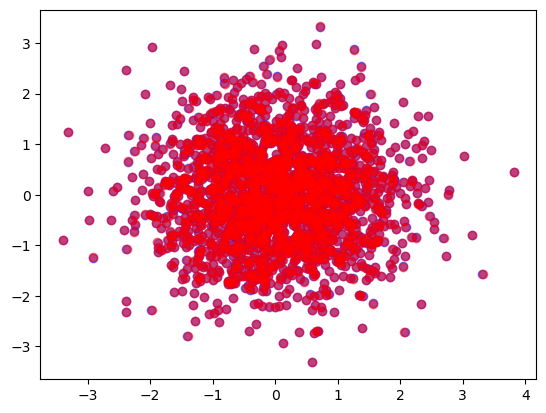

In [6]:
key,subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, (2000, dim))
y = parametric_model(samples = z_samples,params=init_params)

plt.scatter(z_samples[:,0],z_samples[:,1],c='blue',alpha=0.5)
plt.scatter(y[:,0],y[:,1],c='red',alpha=0.5)

In [7]:
G_mat_flow = G_matrix(parametric_model)
solver = "cg"  # minres or cg

In [8]:
from functionals.functions import double_well_potential_fn, styblinski_tang_potential_fn, aggregation_potential_fn,zero_potential_fn
linear_potential = LinearPotential(potential_fn= styblinski_tang_potential_fn, coeff = 1.0)
internal_potential = InternalPotential(functional='entropy', coeff = 1, method= 'hutchinson',prob_dim=dim)
interaction_potential = InteractionPotential(interaction_fn = aggregation_potential_fn, coeff = 10, a = 4, b = 2)

potential = Potential(linear = linear_potential,
                      internal = internal_potential,
                      interaction = None)

In [9]:
# Anderson parameters
h = 1e-3 # Time step size
m = 8# Number of previous iterates to consider
beta = 1.75 # Damping parameter
max_iterations = 300
tolerance = 1e-4
l2_reg_gamma = 1e-4
n_samples = 5_000  # Monte Carlo sample size

key = jax.random.PRNGKey(1234)
rngs = nnx.Rngs(key)


# Generate reference samples from λ = N(0, I)
key, subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, (n_samples, dim))

G_mat_flow = G_matrix(parametric_model)


Starting Anderson-accelerated gradient flow
  n_iterations: 300
  step_size: 0.001
  memory_size: 8
  mixing_parameter: 1.75
------------------------------------------------------------
Iter    0 | Energy: -1.195346e+03 | Residual: 4.475819e-02 | 


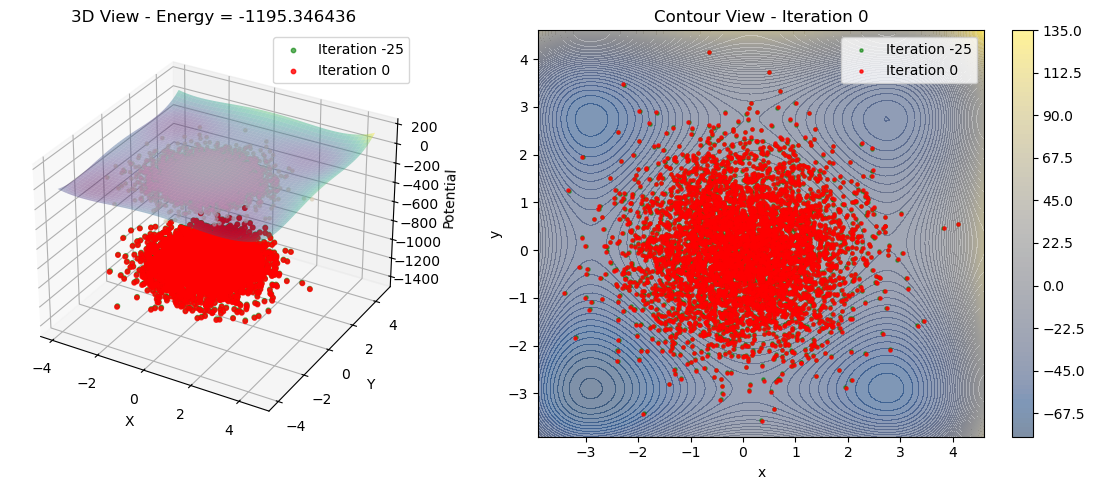

Iter    1 | Energy: -1.210665e+03 | Residual: 3.487049e-02 | 


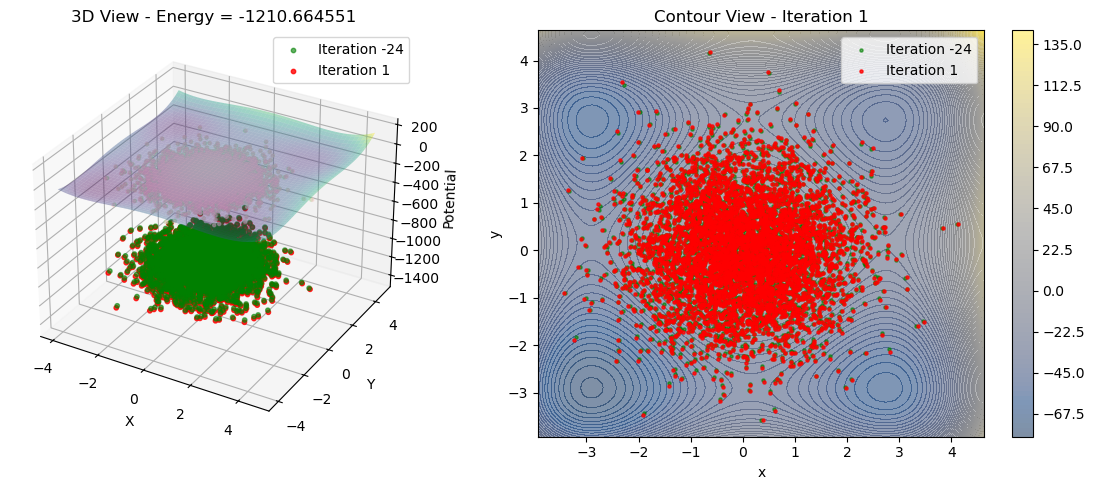

Iter    2 | Energy: -1.229025e+03 | Residual: 3.088819e-02 | 


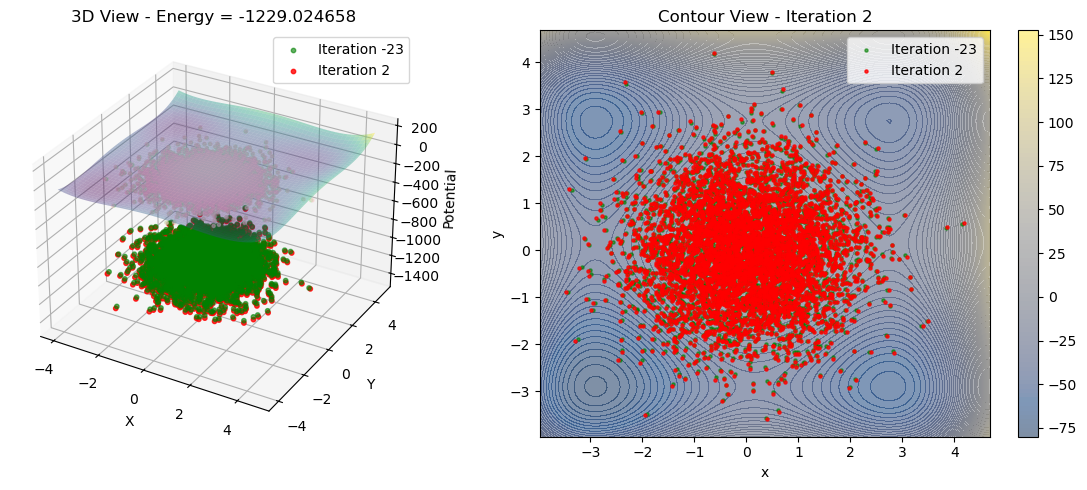

Iter    3 | Energy: -1.256391e+03 | Residual: 2.869157e-02 | 


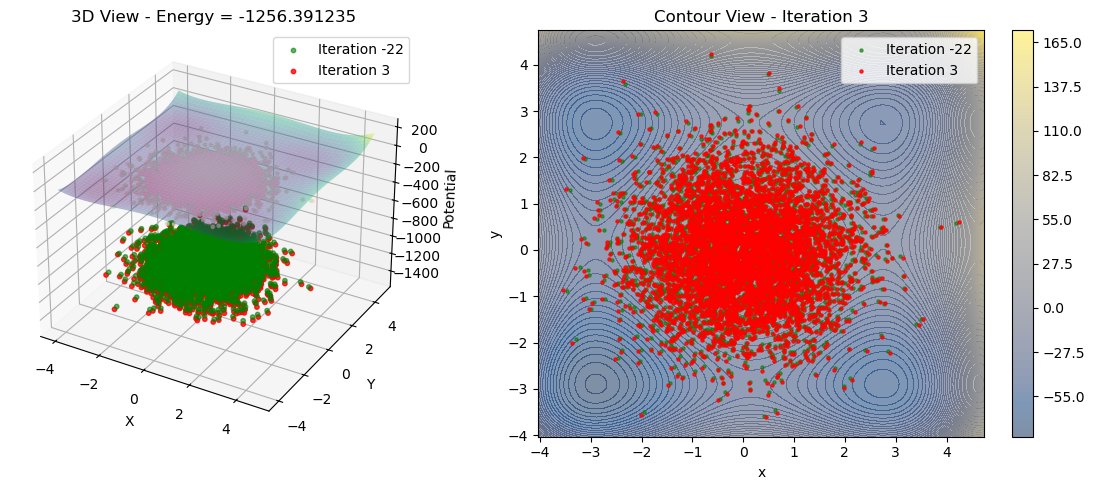

Iter    4 | Energy: -1.292540e+03 | Residual: 2.715817e-02 | 


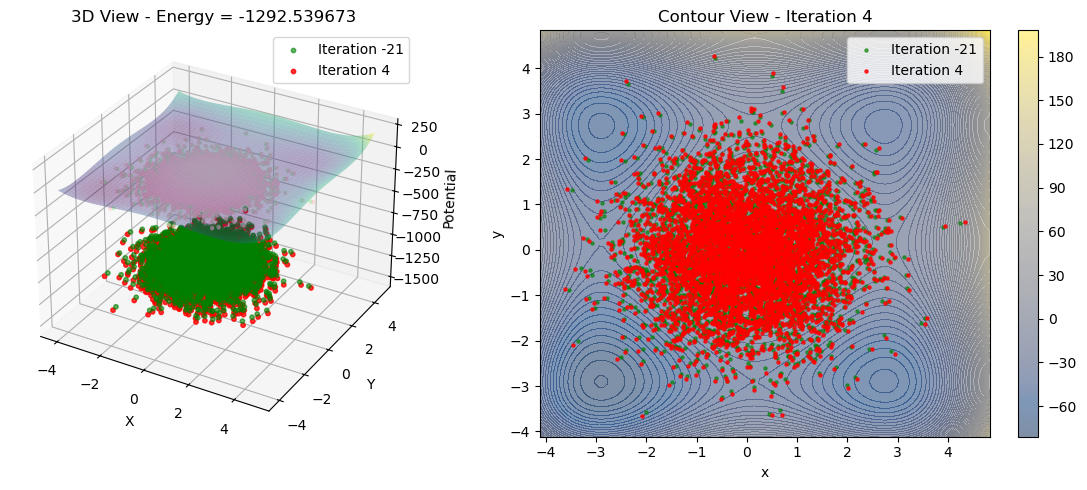

In [ ]:
current_params, history = anderson_method(
    parametric_model, 
    n_samples, 
    z_samples, 
    G_mat_flow, 
    potential,
    solver=solver,
    initial_params=init_params,
    n_iterations=max_iterations, 
    step_size=h, 
    memory_size=m, 
    relaxation=beta, 
    solver_tol= tolerance,
    l2_reg_gamma=l2_reg_gamma,
    plot_intermediate=True,
    plot_frequency=25
)

In [ ]:
samples = parametric_model(samples = z_samples,params=current_params)

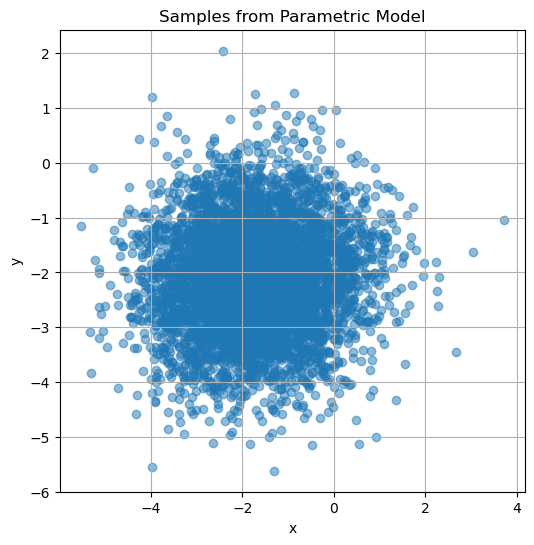

In [ ]:


plt.figure(figsize=(6,6))   
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Samples from Parametric Model')
plt.grid(True)
plt.show()

In [ ]:
# Define the parametric model
# dim = 2
parametric_model_gf = ParametricModel(
    parametric_map="node",  # "node" "resnet"
    rhs_model="mlp",  # "mlp" or "resnet"
    architecture=[dim, 3, 128],  # [input_dim, num_layers, hidden_width]
    activation_fn="tanh",  # "tanh", "relu", "SinTu", "identity", "sigmoid", "gelu", "swish"
    time_dependent=True,  # True or False
    solver="euler",  # "euler" or "heun"
    dt0=0.1, 
    ref_density="gaussian",
    scale_factor=5e-1,
)
# _,init_params = nnx.split(parametric_model)


In [ ]:


# Gradient flow parameters
h = 1e-3 # Time step size2
# max_iterations = 500
# tolerance = 1e-6
# n_samples = 10_000  # Monte Carlo sample size


key = jax.random.PRNGKey(1234)
rngs = nnx.Rngs(key)


# Generate reference samples from λ = N(0, I)
key, subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, (n_samples, dim))

G_mat_flow = G_matrix(parametric_model_gf)

solver= 'cg'



Gradient Flow Progress:   0%|          | 0/300 [00:00<?, ?it/s]2026-01-25 15:17:16.548038: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-01-25 15:17:17.365292: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-01-25 15:17:17.919743: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead

Iter  25: Energy = -1645.746216, Grad norm: 1.68e+02


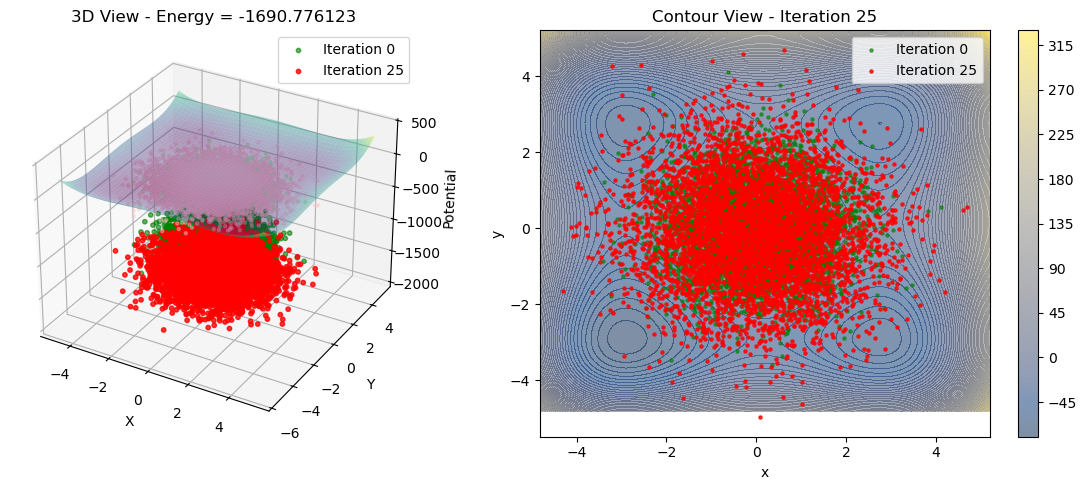

Gradient Flow Progress:  17%|█▋        | 50/300 [03:41<15:37,  3.75s/it, Energy=-1853.187744, Linear=-1607.568970, Internal=-245.618790, Interaction=0.000000]

Iter  50: Energy = -1853.187744, Grad norm: 2.71e+02


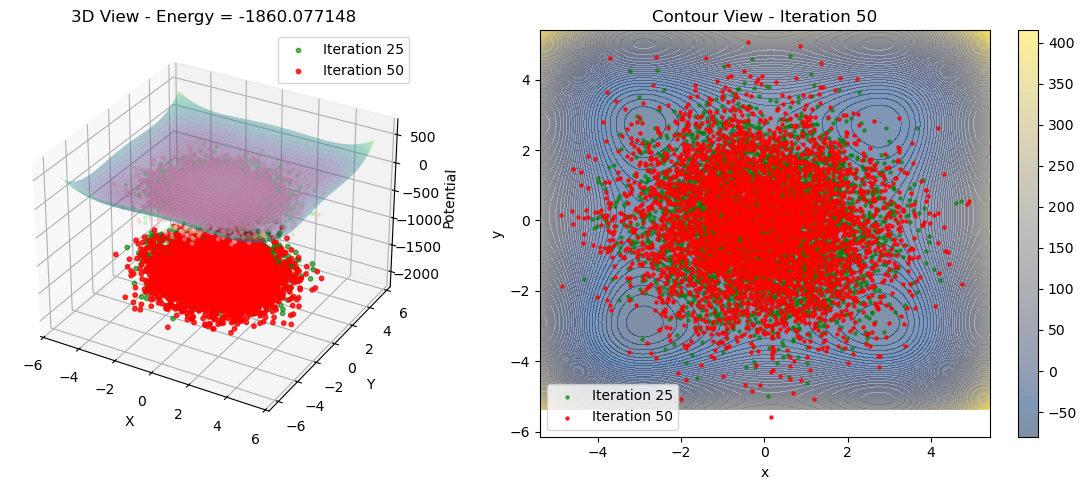

Gradient Flow Progress:  25%|██▌       | 75/300 [05:16<14:00,  3.73s/it, Energy=-1960.609131, Linear=-1710.485229, Internal=-250.123901, Interaction=0.000000]

Iter  75: Energy = -1960.609131, Grad norm: 3.46e+02


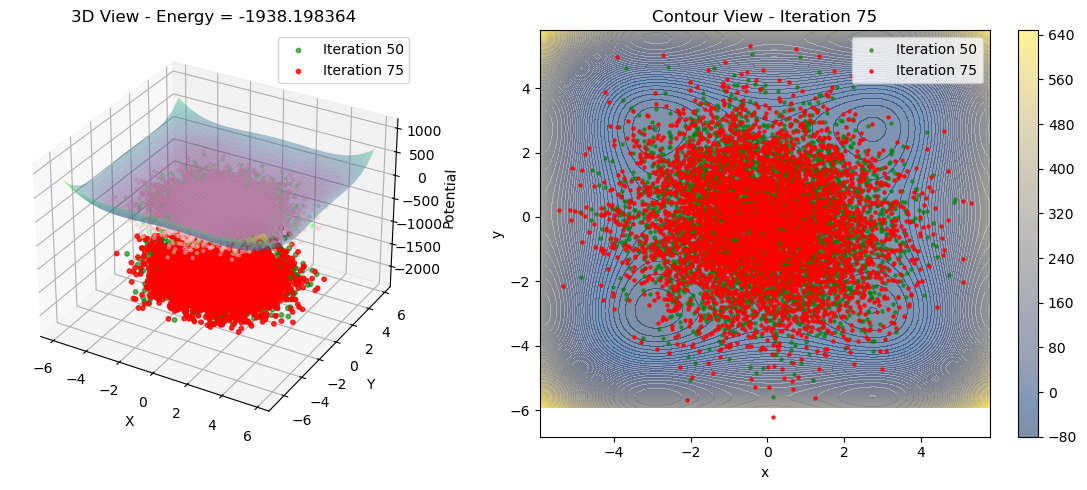

Gradient Flow Progress:  33%|███▎      | 100/300 [06:51<12:27,  3.74s/it, Energy=-2018.952393, Linear=-1768.464966, Internal=-250.487411, Interaction=0.000000]

Iter 100: Energy = -2018.952393, Grad norm: 4.17e+02


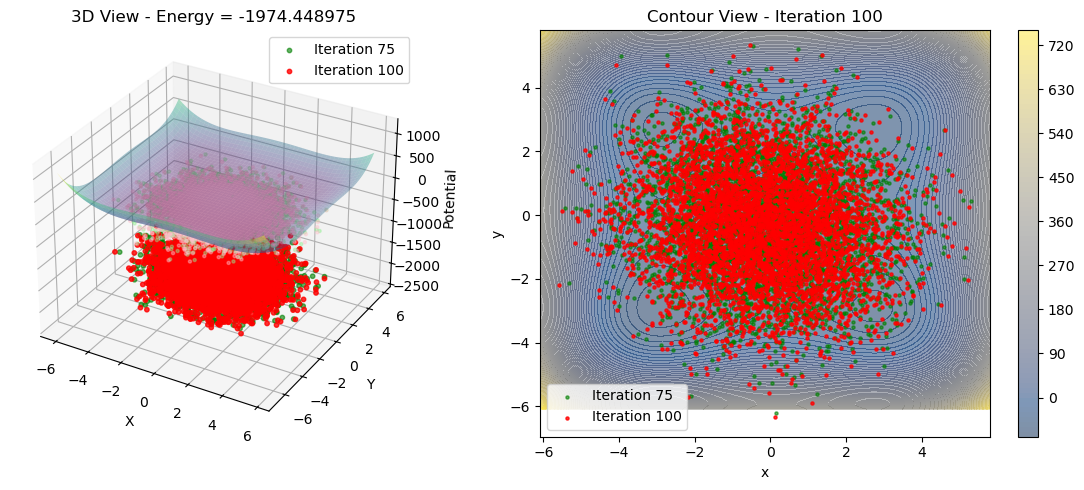

Gradient Flow Progress:  42%|████▏     | 125/300 [08:27<11:17,  3.87s/it, Energy=-1995.406128, Linear=-1746.492432, Internal=-248.913742, Interaction=0.000000]

Iter 125: Energy = -1995.406128, Grad norm: 4.72e+02


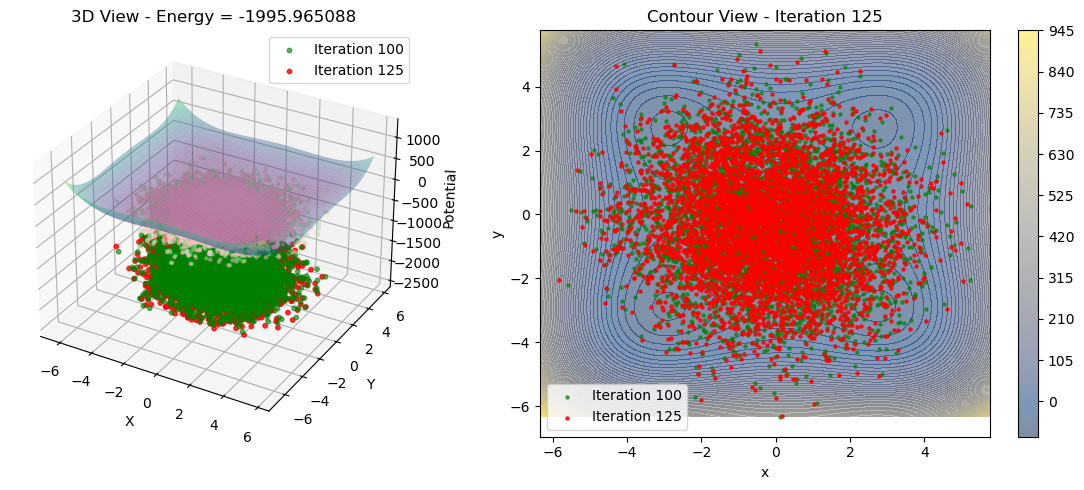

Gradient Flow Progress:  50%|█████     | 150/300 [10:02<09:25,  3.77s/it, Energy=-2029.595337, Linear=-1781.568726, Internal=-248.026642, Interaction=0.000000]

Iter 150: Energy = -2029.595337, Grad norm: 4.63e+02


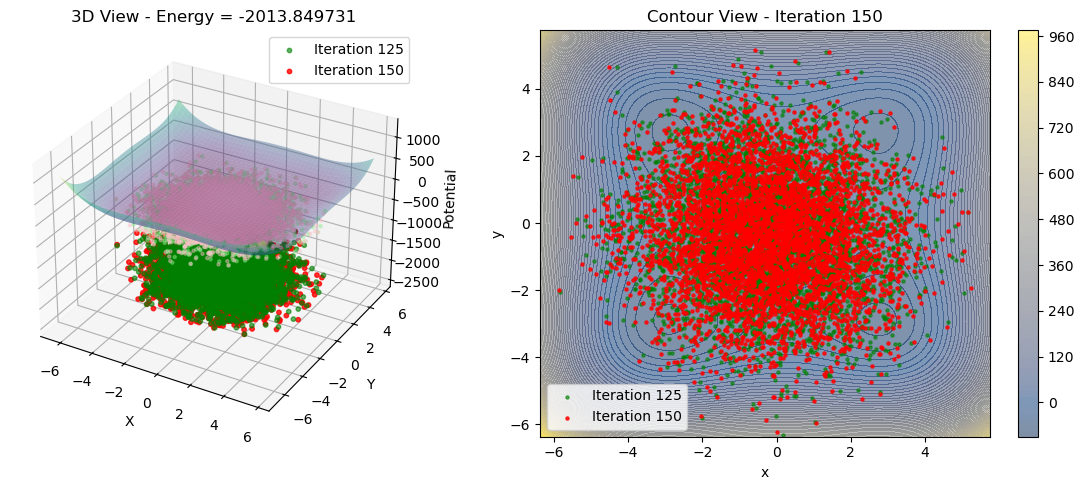

Gradient Flow Progress:  58%|█████▊    | 175/300 [11:37<07:47,  3.74s/it, Energy=-2029.864258, Linear=-1781.395996, Internal=-248.468262, Interaction=0.000000]

Iter 175: Energy = -2029.864258, Grad norm: 4.83e+02


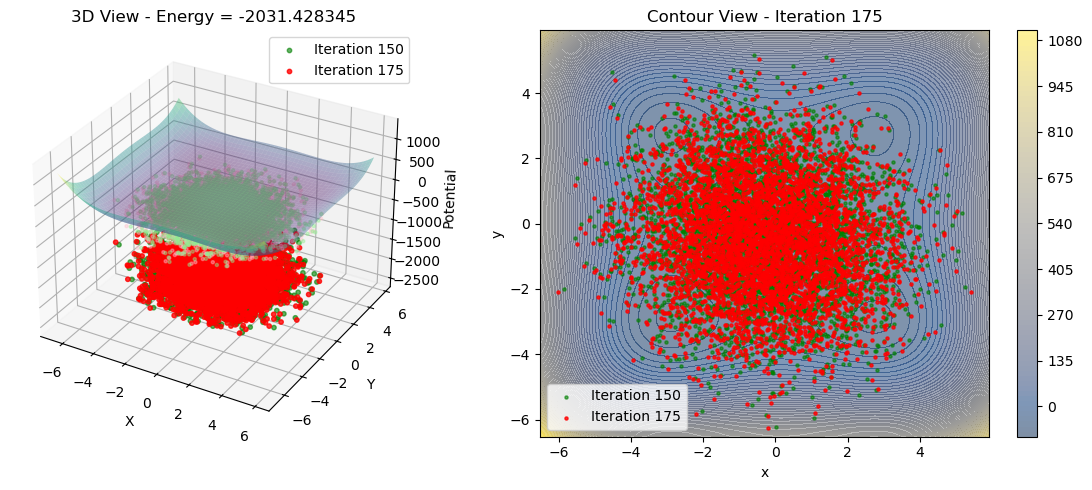

Gradient Flow Progress:  67%|██████▋   | 200/300 [13:13<06:14,  3.75s/it, Energy=-2106.741699, Linear=-1861.046509, Internal=-245.695236, Interaction=0.000000]

Iter 200: Energy = -2106.741699, Grad norm: 4.60e+02


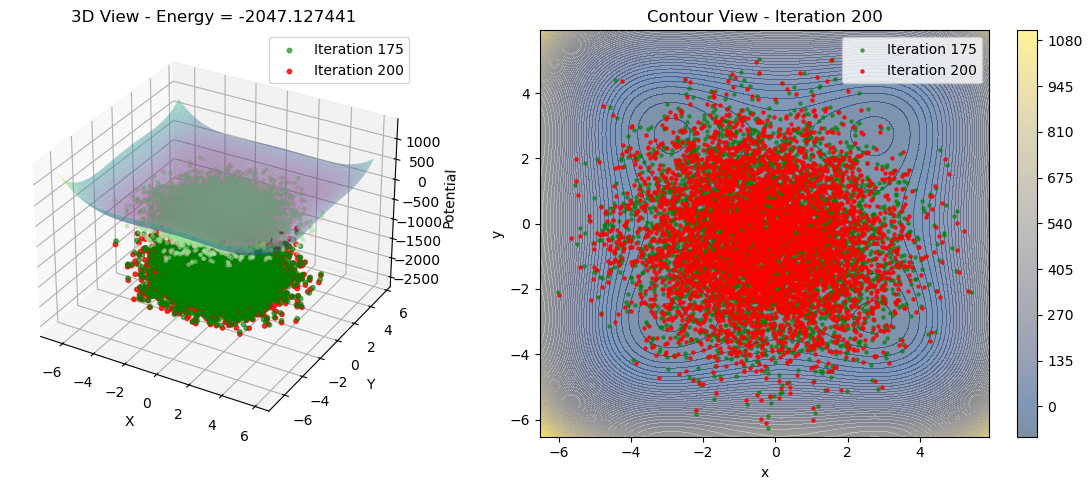

Gradient Flow Progress:  75%|███████▌  | 225/300 [14:48<04:41,  3.75s/it, Energy=-2093.252441, Linear=-1846.223145, Internal=-247.029404, Interaction=0.000000]

Iter 225: Energy = -2093.252441, Grad norm: 4.67e+02


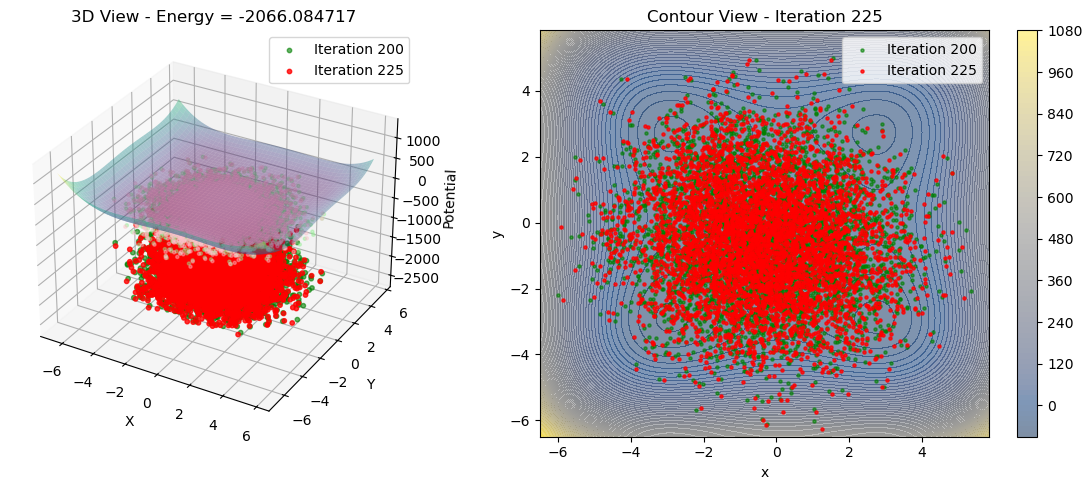

Gradient Flow Progress:  83%|████████▎ | 250/300 [16:25<03:08,  3.77s/it, Energy=-2081.750488, Linear=-1835.224609, Internal=-246.525970, Interaction=0.000000]

Iter 250: Energy = -2081.750488, Grad norm: 4.94e+02


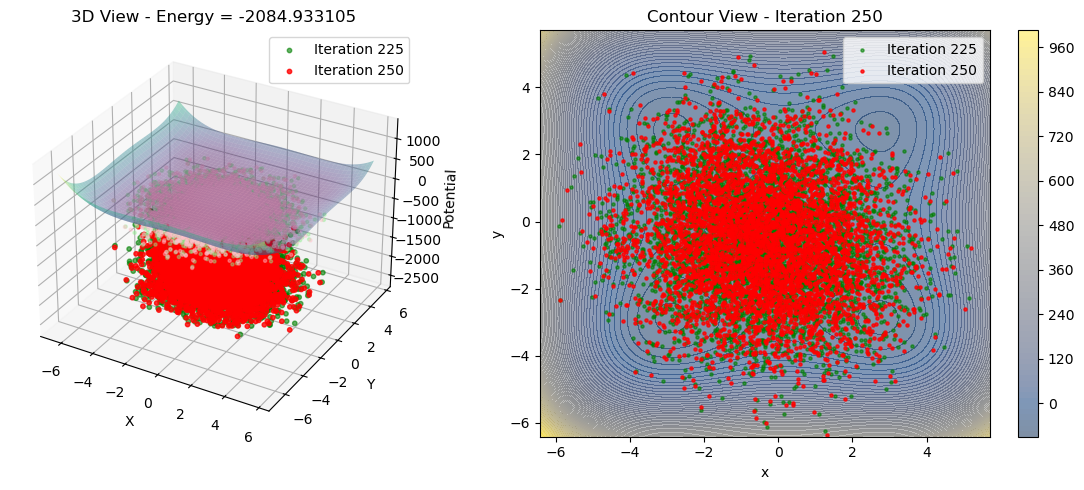

Gradient Flow Progress:  92%|█████████▏| 275/300 [18:00<01:33,  3.74s/it, Energy=-2120.313965, Linear=-1875.933960, Internal=-244.380066, Interaction=0.000000]

Iter 275: Energy = -2120.313965, Grad norm: 4.64e+02


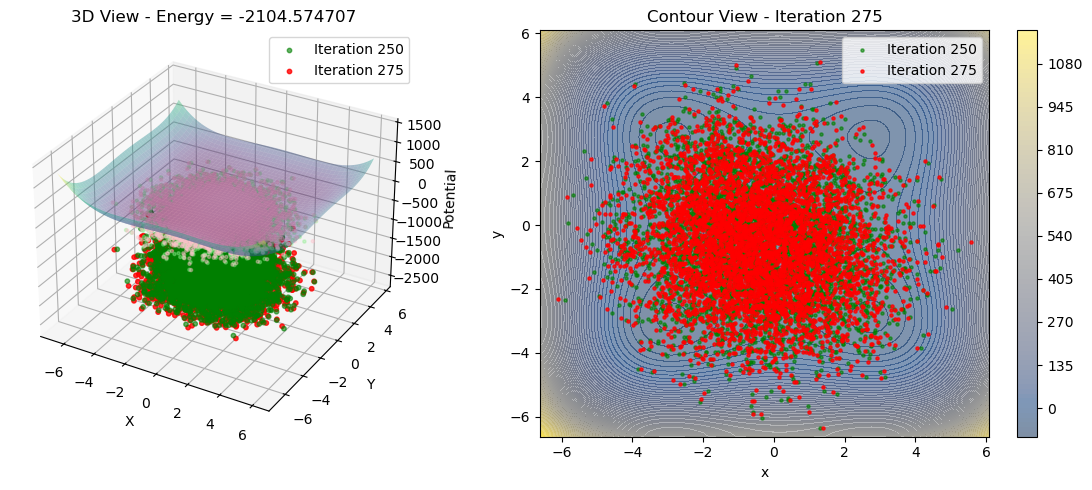

Gradient Flow Progress:  99%|█████████▉| 298/300 [19:29<00:07,  3.81s/it, Energy=-2124.759033, Linear=-1879.529297, Internal=-245.229767, Interaction=0.000000]

Iter 298: Energy = -2124.759033, Grad norm: 4.75e+02


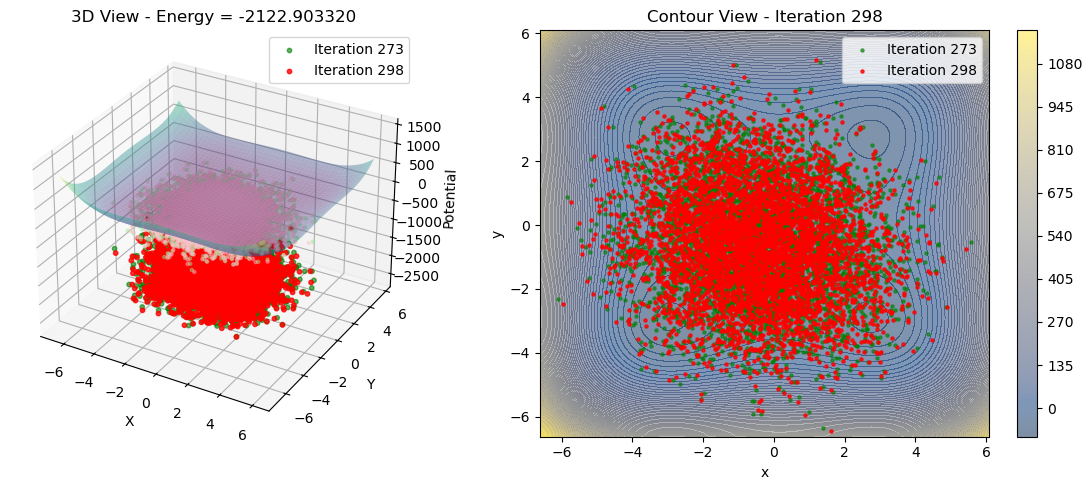

Gradient Flow Progress: 100%|██████████| 300/300 [19:34<00:00,  3.91s/it, Energy=-2107.743896, Linear=-1863.018066, Internal=-244.725891, Interaction=0.000000]



=== Integration Complete ===
Total iterations:    300
Initial energy:      -1189.871948
Final energy:        -2123.653564
Total decrease:      933.781616
Reduction ratio:     1.7848
Final param norm:    34.227604


In [ ]:


results = run_gradient_flow(
    parametric_model_gf, z_samples, G_mat_flow,
    potential
    ,solver=solver,
    h=h, max_iterations=max_iterations, tolerance=tolerance,
    progress_every=25,regularization=1e-4
)



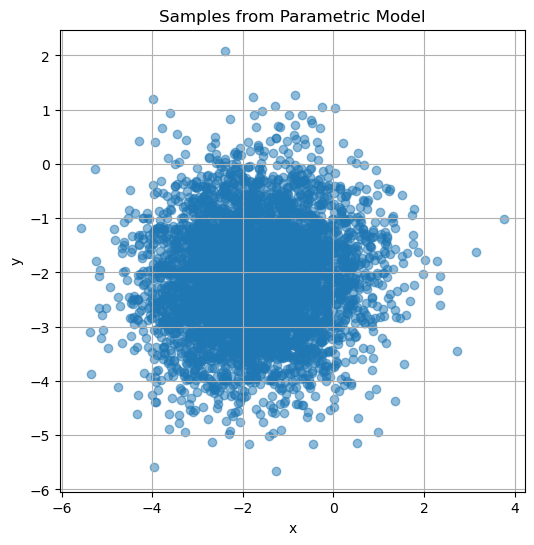

In [ ]:
samples = parametric_model_gf(samples = z_samples,params=current_params)

plt.figure(figsize=(6,6))   
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Samples from Parametric Model')
plt.grid(True)
plt.show()

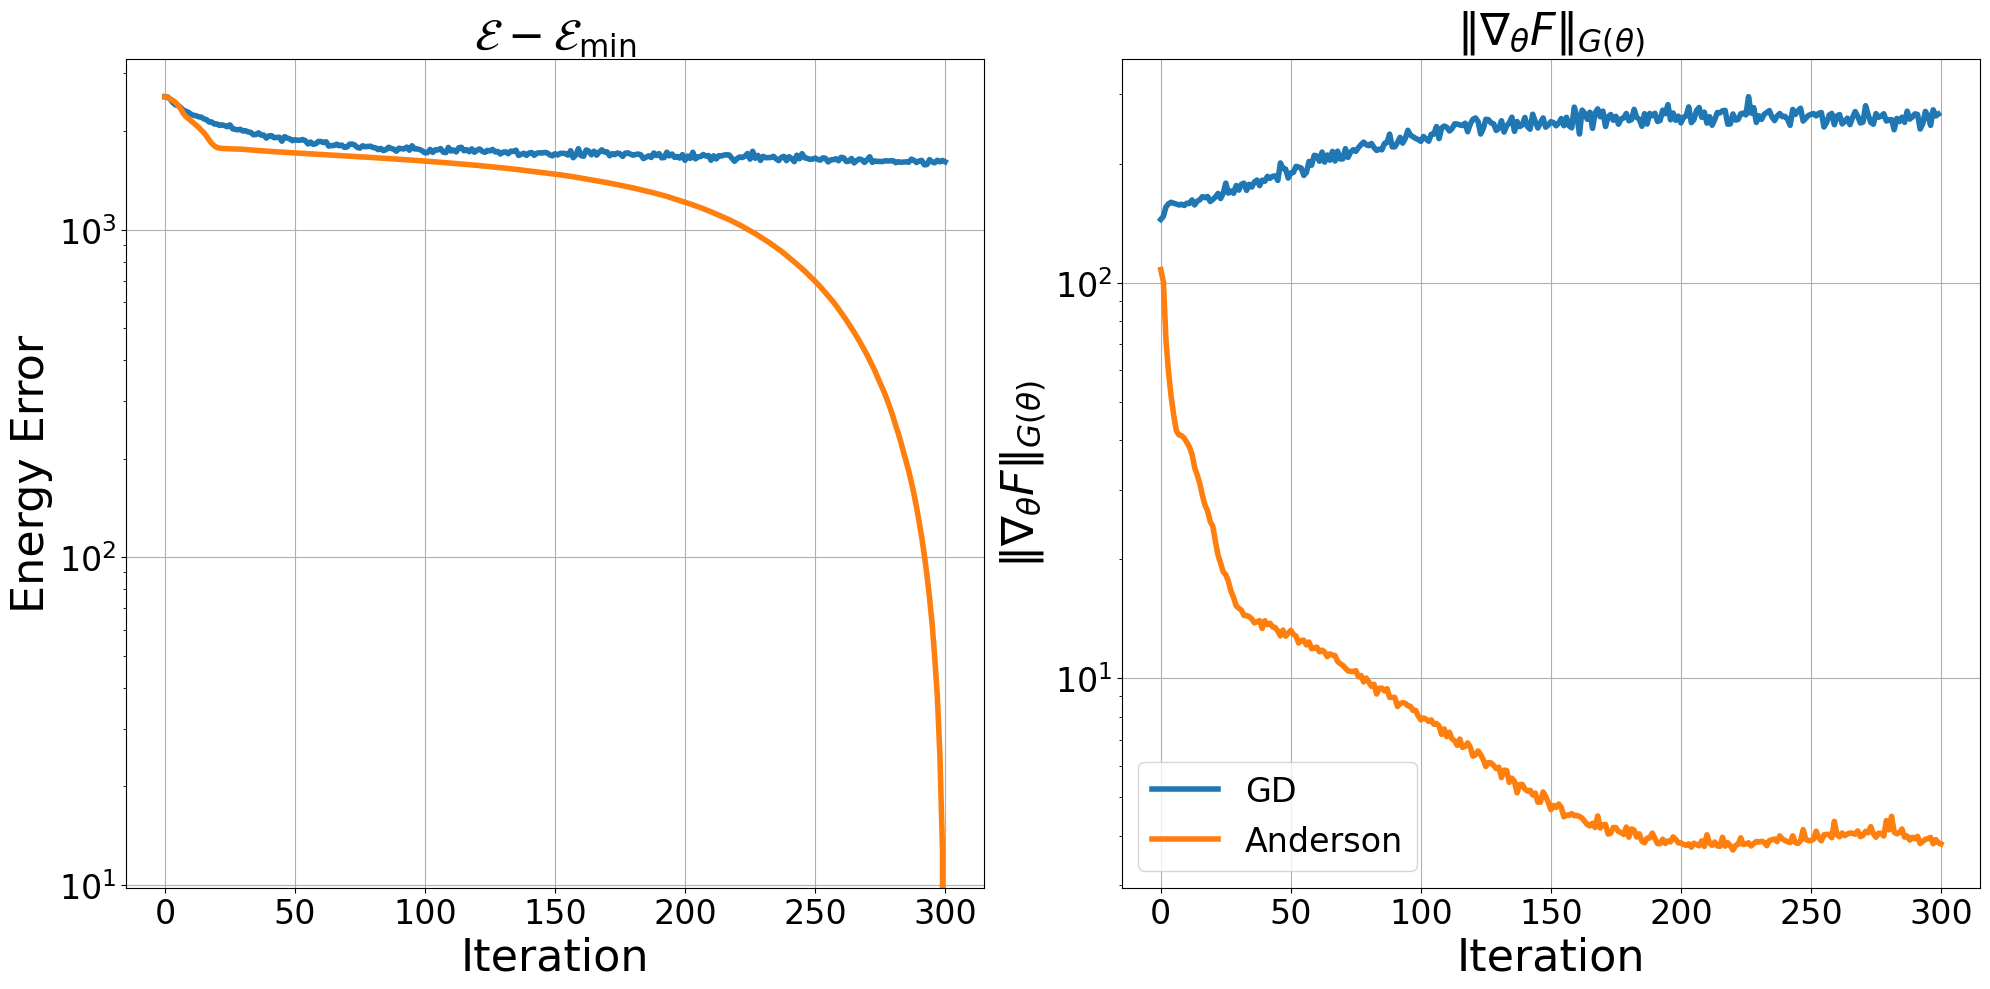

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(20,10))
ax = axs[0]
e_gd = results["energy_history"]
e_gd = jnp.array(e_gd)
e_am = history["energies"]
e_am = jnp.array(e_am)
e_min = jnp.min(jnp.concatenate((e_gd, e_am))) - 1e-10
e_gd -= e_min  # so that we can safely plot in log scale
e_am -= e_min
ax.plot(e_gd, label='GD', linewidth=4)
ax.plot(e_am, label='Anderson', linewidth=4)
ax.tick_params(axis='both', which='major', labelsize=24)
ax.set_yscale("log")
ax.set_xlabel('Iteration',fontsize=32)
ax.set_ylabel('Energy Error',fontsize=32)
# ax.set_ylim(1e-2, None)
ax.grid()
ax.set_title(r'$\mathcal{E} - \mathcal{E}_{\text{min}}$', fontsize=32)

ax = axs[1]

ax.plot(results['riemann_grad_norm_history'], label='GD',linewidth=4)
ax.plot(history['riemann_grad_history'], label='Anderson', linewidth=4)
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=24)
ax.grid()
ax.set_title(r"$\| \nabla_\theta F\|_{G(\theta)}$", fontsize=32)
ax.set_xlabel('Iteration',fontsize=32)
ax.set_ylabel(r'$\| \nabla_\theta F\|_{G(\theta)}$', fontsize=32)

# ax = axs[2]
# ax.plot(history['euclid_grad_norm_history'], label='GD')
# ax.set_yscale('log')
# ax.grid()
# ax.set_title(r"$\| \nabla_\theta F\|_2$")

axs[-1].legend(fontsize=24)

fig.tight_layout()
fig.savefig('GD_vs_AM.pdf')